In [26]:
import numpy as np
import matplotlib.pyplot as plt
def sample_prior(m, L, rng=None):
    """
    Draw a sample from a Gaussian prior  N(m, C)
    where C = L @ L.T.

    Inputs:
        m  : mean vector (n,)
        L  : covariance square root (n,n)
             such that C = L L^T 
        rng: optional numpy generator

    Output:
        u ~ N(m, C)
    """
    if rng is None:
        rng = np.random.default_rng()

    z = rng.normal(size=L.shape[0])   # z ~ N(0,I)
    return m + L @ z                  # u = m + L z


In [27]:
m=np.array([0])
L=np.array([1])

In [28]:
u = sample_prior(m, L)   # starting point from the prior
print(u)


[-2.06541805]


In [33]:
import numpy as np

def sample_prior(m, L, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    z = rng.normal(size=L.shape[0])
    return m + L @ z

def pcn(loglik, m, L, beta=0.1, n_samples=1000000, burn=5000, thin=1, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    n = L.shape[0]
    chain = np.zeros((n_samples, n))

    # initialize from the prior
    u = sample_prior(m, L, rng)
    logl_u = loglik(u)

    accepts = 0

    for k in range(n_samples):
        # draw xi ~ N(0, C)
        xi = sample_prior(np.zeros(n), L, rng)

        # proposal
        u_prop = np.sqrt(1-beta**2)*u + beta*xi

        logl_prop = loglik(u_prop)
        log_alpha = logl_prop - logl_u

        if np.log(rng.uniform()) < log_alpha:
            u = u_prop
            logl_u = logl_prop
            accepts += 1

        chain[k] = u

    print("Acceptance rate:", accepts / n_samples)
    return chain[burn::thin]


In [40]:
sigma = 0.1
y_obs = 0.3

m = np.array([0.0])    # prior mean
L = np.array([[1.0]])  # prior sqrt => N(0,1)

def loglik(u):
    u = u[0]
    return -0.5*((y_obs - u**2)/sigma)**2

samples = pcn(loglik, m, L, beta=0.2)


Acceptance rate: 0.504821


In [41]:
def plot_posterior_vs_true_1d(samples, grid, true_pdf, bins=60):
    """
    Compare histogram of samples with true (normalized) posterior PDF.
    """
    samples = np.asarray(samples).flatten()

    plt.figure(figsize=(7,4))

    # histogram
    plt.hist(samples, bins=bins, density=True, alpha=0.4, edgecolor="k",
             label="pCN posterior samples")

    # true posterior curve
    plt.plot(grid, true_pdf, "r-", lw=2, label="True posterior")

    plt.xlabel("u")
    plt.ylabel("Density")
    plt.title("Posterior: pCN vs true")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


/tmp/ipykernel_3212615/1149897149.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  true_pdf = pdf_unnorm / np.trapz(pdf_unnorm, u_grid)


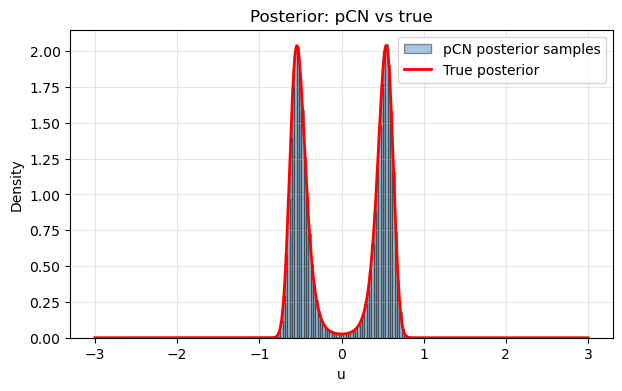

In [42]:
# build grid
u_grid = np.linspace(-3, 3, 2000)

# true posterior (unnormalized)
log_post = -0.5*u_grid**2 - (y_obs - u_grid**2)**2/(2*sigma**2)
pdf_unnorm = np.exp(log_post - np.max(log_post))
true_pdf = pdf_unnorm / np.trapz(pdf_unnorm, u_grid)

plot_posterior_vs_true_1d(samples, u_grid, true_pdf)
